In [1]:
import tensorflow as tf 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import pylab as rcParams 
import warnings 
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
import keras 
from keras.models import Sequential 
from keras.layers import Dropout,Dense 
from keras.callbacks import EarlyStopping 
from sklearn.model_selection import train_test_split as tts 
from sklearn.datasets import make_circles 
import seaborn as sns 

In [2]:
X,y = make_circles(n_samples=100,noise=0.1,random_state=1)

<Axes: >

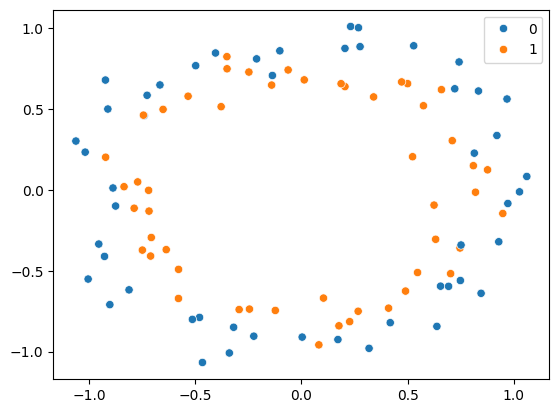

In [4]:
# pass x and y as keyword arguments (seaborn scatterplot does not accept two positional arguments)
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y)

In [5]:
X_train,X_test,y_train,y_test = tts(X,y,test_size=0.20, random_state=2)

In [6]:
model = Sequential()

model.add(Dense(256,input_dim=2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

c:\Users\rudra\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [8]:
history = model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=3500, verbose=0)

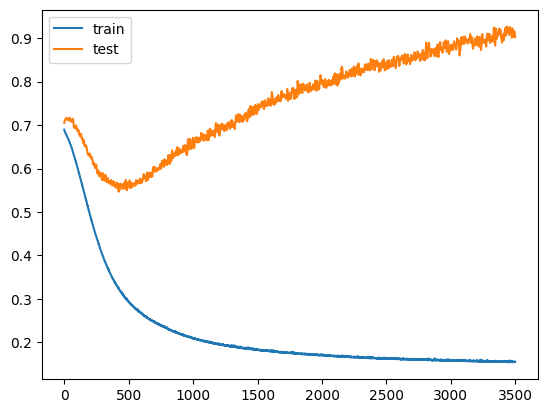

In [9]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

In [10]:
# the gaps is showing it is overfitting

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


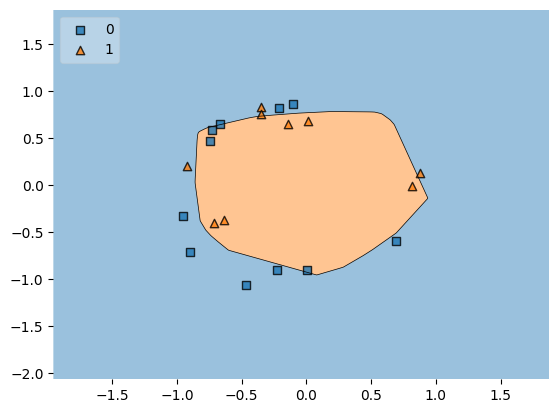

In [11]:
plot_decision_regions(X_test,y_test.ravel(), clf=model, legend=2)
plt.show()

In [35]:
# Applying Early Stopping
model = Sequential()

model.add(Dense(256,input_dim=2, activation='relu'))
model.add(Dense(1,activation='sigmoid'))

c:\Users\rudra\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


In [37]:
callback = EarlyStopping(
    monitor='val_loss',
    min_delta=0.000001,
    patience=20,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=False
)

In [34]:
history = model.fit(X_train, y_train, validation_data=(X_test,y_test), epochs=3500, callbacks=callback)

Epoch 1/3500
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5000 - loss: 0.6697

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.5625 - loss: 0.6662 - val_accuracy: 0.4000 - val_loss: 0.7213
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5750 - loss: 0.6657 - val_accuracy: 0.4000 - val_loss: 0.7213
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 0.5750 - loss: 0.6650 - val_accuracy: 0.4000 - val_loss: 0.7212
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 301ms/step - accuracy: 0.5875 - loss: 0.6644 - val_accuracy: 0.4000 - val_loss: 0.7218
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5875 - loss: 0.6637 - val_accuracy: 0.4000 - val_loss: 0.7214
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5875 - loss: 0.6630 - val_accuracy: 0.4000 - val_loss: 0.7215
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.5750 - loss: 0.6626 - val_accuracy: 0.4000 - val_loss: 0.7223
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5750 - loss: 0.6618 - val_accuracy: 0.4000 - val_loss: 

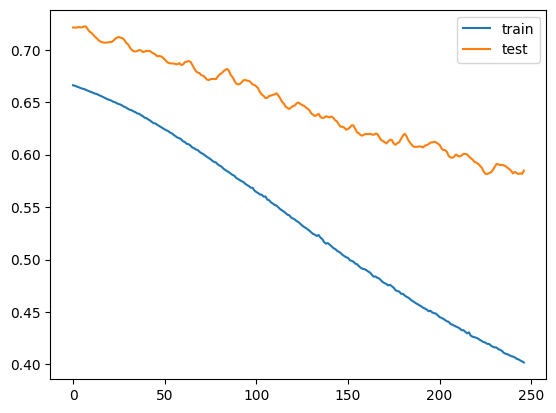

In [38]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step


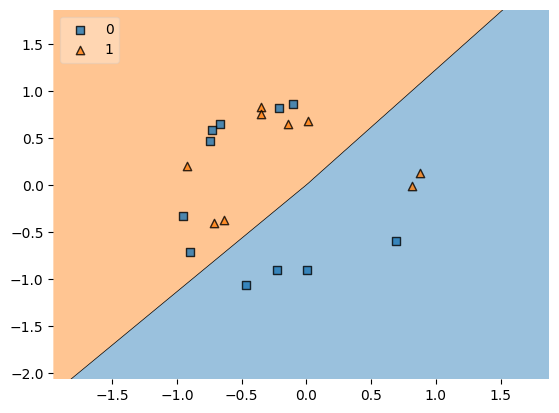

In [39]:
plot_decision_regions(X_test,y_test.ravel(), clf=model, legend=2)
plt.show()